# Figure 1i — inputs

Two properties predict how much unproductive splicing a locus carries: long
introns carry more of it, and lowly expressed genes carry more of it.

The measurements come from **Geuvadis**: 373 lymphoblastoid cell lines from the
European populations of the 1000 Genomes Project, steady-state mRNA-seq. This is
a different cohort from the GTEx figures, and from the four perturbations in
Fig. 1g.

This notebook computes the two tables the panel is drawn from. The unproductive
fraction is computed per cluster and per gene **in each of the 373 samples**, and
then summarised across them — mean for the intron-length panel, median for the
expression panel. So each row below is one cluster or one gene, not one sample.

| Table | One row per | Carries |
|---|---|---|
| `fig1i_intron_length.tsv` | cluster with both productive and unproductive introns | mean unproductive fraction, length of the most-used productive intron |
| `fig1i_expression.tsv` | gene | median unproductive fraction, mean RPKM |

The panel itself is drawn in `Figure1.ipynb`.

In [1]:
suppressMessages({
    library(data.table)
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(cowplot)
})

SPLIFI   <- '/project/yangili1/cfbuenabadn/SpliFi'
ANALYSIS <- file.path(SPLIFI, 'analysis')
GTF      <- '/project/yangili1/cdai/annotations/hg38/gencode.v43.primary_assembly.annotation.gtf.gz'
OUT      <- 'figure_data'
PLOTS    <- 'plots'
dir.create(OUT, showWarnings = FALSE)
dir.create(PLOTS, showWarnings = FALSE)
options(repr.plot.width = 10, repr.plot.height = 4)

## Read counts and unproductive fractions

`cts` is the leafcutter2 junction-count matrix; `stored` holds the unproductive
fraction already computed per cluster and per gene for every sample.

In [2]:
cts <- readRDS(file.path(SPLIFI,
    'data/ExtractFractions/Geuvadis/EUR.numerators_constcounts.noise_by_intron.rds'))
stored <- readRDS(file.path(ANALYSIS, '2024-01-20-Geuvadis.EUR.storedcomputes.rds'))

datcols <- names(cts)[grepl('^(HG|NA)[0-9]', names(cts))]
cat('samples:', length(datcols), '\n')
cat('junctions:', nrow(cts), '\n')
cat('clusters with an unproductive fraction:', nrow(stored$unprod_ratio_by_clu), '\n')
cat('genes with an unproductive fraction:', nrow(stored$unprod_ratio_by_gene), '\n')

samples: 373 


junctions: 228671 


clusters with an unproductive fraction: 113956 


genes with an unproductive fraction: 12987 


## Intron length

Restricted to clusters carrying both productive and unproductive introns. Within
each cluster the **most-used productive intron** supplies the length, so the
comparison is between a cluster's unproductive fraction and the size of the
intron it is competing with.

In [3]:
dt <- copy(cts)[str_detect(clu_type, 'PR\\,UP')]
dt[, intron_length := as.numeric(str_split(chrom, ':', simplify = TRUE)[, 3]) -
                      as.numeric(str_split(chrom, ':', simplify = TRUE)[, 2])]
dt[, meanCount := rowMeans(.SD), .SDcols = datcols]

pr <- dt[intron_type == 'PR'][order(-meanCount), .SD[1], by = clu][, .(clu, intron_length)]

ratio_clu <- as.data.table(stored$unprod_ratio_by_clu)
ratio_clu[, meanUnprod := rowMeans(.SD, na.rm = TRUE), .SDcols = datcols]

len <- merge(pr, ratio_clu[, .(clu, meanUnprod)], by = 'clu')
len <- len[is.finite(meanUnprod) & is.finite(intron_length)]
len[, intron_length_bin := cut(intron_length,
      breaks = c(0, 1000, 5000, 20000, 50000, Inf),
      labels = c('<1kb', '1-5kb', '5-20kb', '20-50kb', '>50kb'), right = FALSE)]

ct <- suppressWarnings(cor.test(len$meanUnprod, len$intron_length, method = 'spearman'))
cat(sprintf('n = %d clusters   Spearman rho = %.3f   P = %.3g\n',
            nrow(len), ct$estimate, ct$p.value))
len[, .(n = .N, median_unproductive = round(median(meanUnprod), 4)), by = intron_length_bin][order(intron_length_bin)]

n = 16841 clusters   Spearman rho = 0.143   P = 4.61e-78


intron_length_bin,n,median_unproductive
<fct>,<int>,<dbl>
<1kb,5210,0.0153
1-5kb,7062,0.0176
5-20kb,3307,0.0233
20-50kb,924,0.0315
>50kb,338,0.0450


## Gene expression

RPKM per gene: total junction reads over the genomic span of the gene, then
averaged across samples and cut at its own quintiles.

Gene length is `end - start` of protein-coding `gene` features in GENCODE v43.

In [4]:
gtf <- fread(cmd = paste('zcat', GTF, '| awk -F\'\\t\' \'$3=="gene"\''),
             header = FALSE, sep = '\t', select = c(4, 5, 9),
             col.names = c('start', 'end', 'attr'))
gtf <- gtf[grepl('gene_type "protein_coding"', attr)]
gtf[, gene_name := sub('.*gene_name "([^"]+)".*', '\\1', attr)]
gtf[, gene_len := end - start]
gene_lens <- gtf[, .(gene_len = max(gene_len)), by = gene_name]
cat('protein-coding genes with a length:', nrow(gene_lens), '\n')

protein-coding genes with a length: 20013 


In [5]:
juncClass <- fread(file.path(SPLIFI,
    'code/results/pheno/noisy/Geuvadis/EUR/wConst_junction_classifications.txt'))
jmap <- unique(juncClass[, .(Intron_coord, Gene_name)])

cts2 <- copy(cts)
cts2[, Intron_coord := paste0(str_split(chrom, ':', simplify = TRUE)[, 1], ':',
                              str_split(chrom, ':', simplify = TRUE)[, 2], '-',
                              str_split(chrom, ':', simplify = TRUE)[, 3])]
cts2 <- merge(cts2, jmap, by = 'Intron_coord', allow.cartesian = FALSE)

total_by_gene <- cts2[, lapply(.SD, sum), by = Gene_name, .SDcols = datcols]
total_by_gene <- merge(total_by_gene, gene_lens, by.x = 'Gene_name', by.y = 'gene_name')

rpkm <- as.data.table(lapply(total_by_gene[, ..datcols],
    function(x) 1e9 * as.double(x) / (sum(as.double(x)) * as.double(total_by_gene$gene_len))))
meanRPKM <- data.table(Gene_name = total_by_gene$Gene_name,
                       meanrpkm = rowMeans(as.matrix(rpkm), na.rm = TRUE))

In [6]:
ratio_gene <- as.data.table(stored$unprod_ratio_by_gene)
ratio_gene[, medUPratio := matrixStats::rowMedians(as.matrix(.SD), na.rm = TRUE),
           .SDcols = datcols]

expr <- merge(ratio_gene[, .(Gene_name, medUPratio)], meanRPKM, by = 'Gene_name')
expr <- expr[medUPratio > 0 & is.finite(meanrpkm)]

qs <- quantile(expr$meanrpkm, seq(0, 1, .2), na.rm = TRUE)
expr[, rpkm_bin := cut(meanrpkm, breaks = c(0, qs[2:5], Inf),
      labels = c('Q1 - lowly expressed', 'Q2', 'Q3', 'Q4', 'Q5 - highly expressed'))]

ct2 <- suppressWarnings(cor.test(expr$medUPratio, expr$meanrpkm, method = 'spearman'))
cat(sprintf('n = %d genes   Spearman rho = %.3f   P = %.3g\n',
            nrow(expr), ct2$estimate, ct2$p.value))
expr[, .(n = .N, median_unproductive = round(median(medUPratio), 4)), by = rpkm_bin][order(rpkm_bin)]

n = 6412 genes   Spearman rho = -0.556   P = 0


rpkm_bin,n,median_unproductive
<fct>,<int>,<dbl>
Q1 - lowly expressed,1283,0.0265
Q2,1282,0.0106
Q3,1282,0.0069
Q4,1282,0.0047
Q5 - highly expressed,1283,0.0022


## Write the tables

`Figure1.ipynb` reads these two files and draws the panel.

In [7]:
write.table(len,  file.path(OUT, 'fig1i_intron_length.tsv'),
            sep = '\t', quote = FALSE, row.names = FALSE)
write.table(expr, file.path(OUT, 'fig1i_expression.tsv'),
            sep = '\t', quote = FALSE, row.names = FALSE)
cat('wrote', nrow(len), 'clusters and', nrow(expr), 'genes to', OUT, '\n')

wrote 16841 clusters and 6412 genes to figure_data 


## The panel

Cumulative distribution of the unproductive fraction, split each way. A zero
fraction cannot go on a log axis, so zeros are floored at 0.05% — the same
treatment the original analysis used.

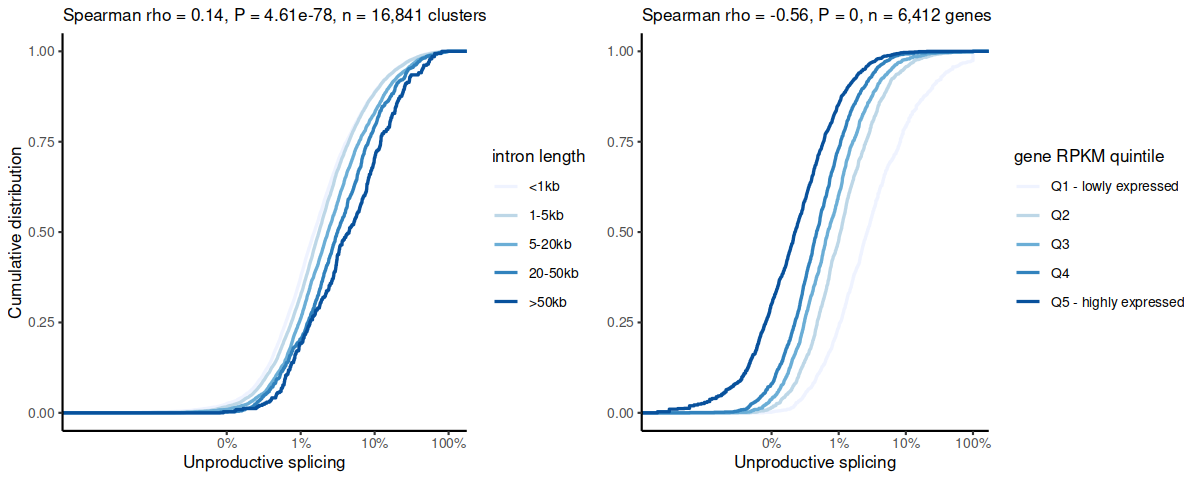

In [8]:
ZERO_FLOOR <- 0.0005

p_len <- ggplot(len) +
    stat_ecdf(aes(x = if_else(meanUnprod == 0, ZERO_FLOOR, meanUnprod),
                  color = intron_length_bin), linewidth = 0.7) +
    scale_color_brewer(palette = 'Blues', name = 'intron length') +
    scale_x_log10(breaks = c(0.001, 0.01, 0.1, 1),
                  labels = c('0%', '1%', '10%', '100%')) +
    labs(x = 'Unproductive splicing', y = 'Cumulative distribution',
         subtitle = sprintf('Spearman rho = %.2f, P = %.3g, n = %s clusters',
                            ct$estimate, ct$p.value, format(nrow(len), big.mark = ','))) +
    theme_classic(base_size = 10)

p_expr <- ggplot(expr) +
    stat_ecdf(aes(x = medUPratio, color = rpkm_bin), linewidth = 0.7) +
    scale_color_brewer(palette = 'Blues', name = 'gene RPKM quintile') +
    scale_x_log10(breaks = c(0.001, 0.01, 0.1, 1),
                  labels = c('0%', '1%', '10%', '100%')) +
    labs(x = 'Unproductive splicing', y = NULL,
         subtitle = sprintf('Spearman rho = %.2f, P = %.3g, n = %s genes',
                            ct2$estimate, ct2$p.value, format(nrow(expr), big.mark = ','))) +
    theme_classic(base_size = 10)

# patchwork 1.1.1 here predates ggplot2 3.5 and errors on save, so the two
# panels are combined with cowplot instead.
fig1i <- cowplot::plot_grid(p_len, p_expr, nrow = 1, labels = NULL)
fig1i

In [9]:
for (ext in c('png', 'pdf', 'svg')) {
    ggsave(file.path(PLOTS, paste0('fig1i.', ext)), fig1i,
           width = 10, height = 4, dpi = 300)
}
cat('wrote', file.path(PLOTS, 'fig1i.{png,pdf,svg}'), '\n')

wrote plots/fig1i.{png,pdf,svg} 
